# Setup

In [49]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

In [50]:
import numpy as np
import torch
from scipy.ndimage import binary_dilation
import matplotlib.pyplot as plt
import cv2

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device type {device.type}")

Device type cuda


# Loading experiment data

Here specify the path to the folder containing all the videos:
- NAME_00123.nd2 files
- NAME_00123_ROI.tiff files
Set the name variable to NAME (e.g. MSH2)

+ PLUS: Add the grouping to the file names
+ WT or KO
+ e.g. NAME_WT_00123.tiff

Tip: use full path e.g /home/user/projects/folder
Tip: use TAB to select the folders

In [52]:
# Modify these to load experiment data from a directory
data_dir = "/mnt/c/Users/sznistvan/Documents/bioinfo/cell_segment_videos/MSH2/EVsint_EVsiutr"
name = "MSH2"

In [53]:
from experiment_loader import ExperimentBatch
batch = ExperimentBatch(name, data_dir)
print(f"Number of experiments in batch: {len(batch.experiments())}")

Number of experiments in batch: 2


## Calculate minumum number of frames for the experiments in the batch

In [54]:
lens = []
for experiment in batch.experiments():
    lens.append(len(experiment.frames_u8()))
min_len = min(lens)
max_len = max(lens)
batch.max_len = min_len
print(f"Minimum number of frames {min_len}")
print(f"Maximum number of frames {max_len}")

Minimum number of frames 242
Maximum number of frames 242


# Generating cell masks

## Config

In [55]:
%load_ext autoreload
%autoreload 1
%aimport image_transforms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
from image_transformer import generate_masks_using_filters_and_transforms
from image_transforms import convert_to_u8, threshold_image, adjust_contrast, set_brightness

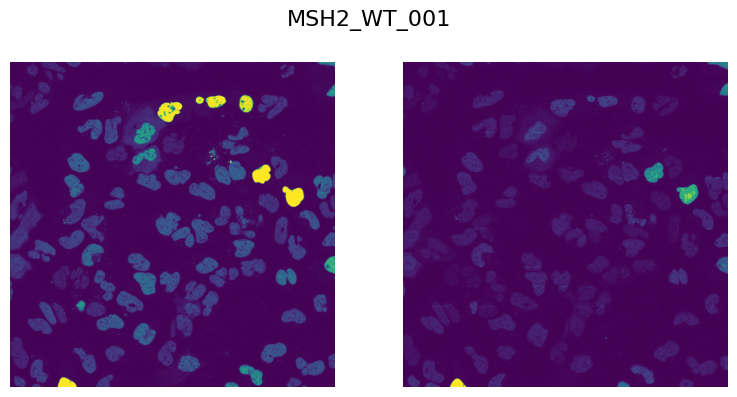

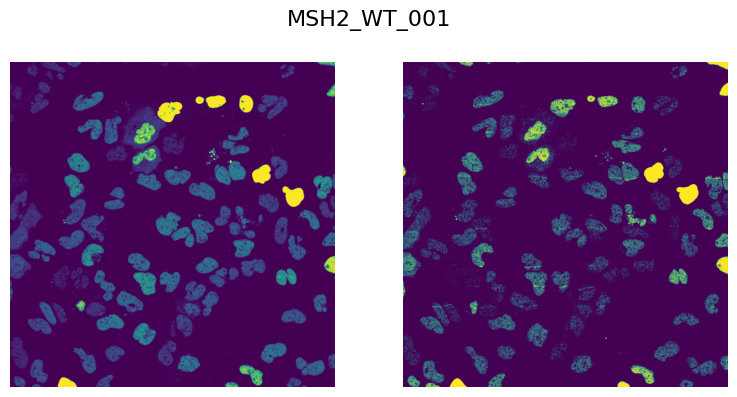

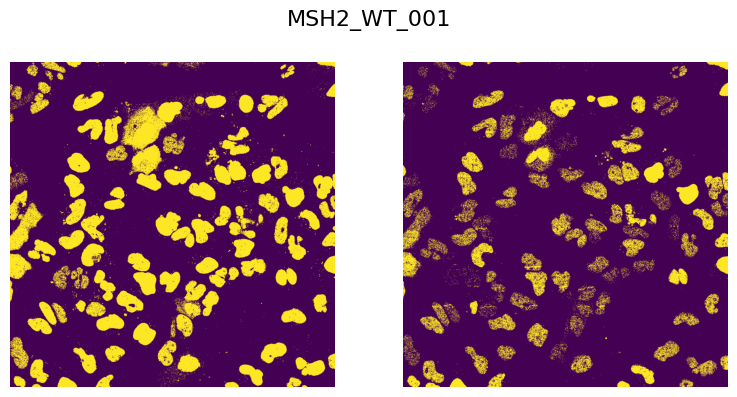

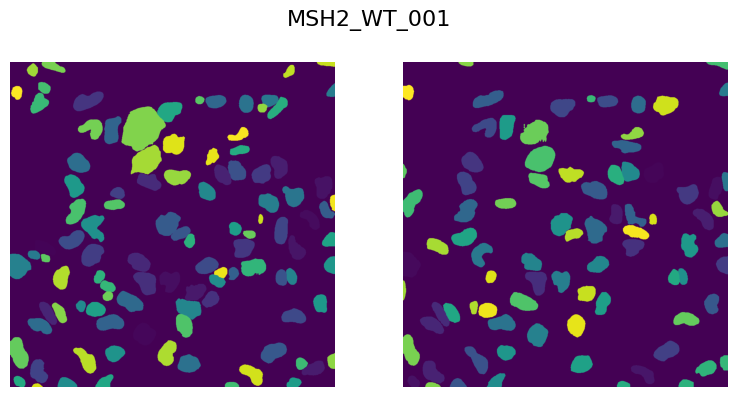

In [57]:
# Filter which experiments from the batch are processed. This can speed up iteration time while tuning the filters
# Possible values:
#     None             all experiments
#     list of numbers  [0, 2, 4] only these experiments
#     string           all experiments containing the string. E.g. 'KO' will show all experiments whose file name includes 'KO'
experiment_filter = [1]
# Which frames to process from each experiment. 
# Possible values:
#     integer           1, 2, 3, etc. Evenly split the experiment interval with N points.
#                       1 will show the first frame, 2 shows the first and last frames, 3 shows first, middle, last
#     list of integers  Show the frames specified in the list, e.g. [0, 10] shows the 0th and 10th frames
frame_filter = 2
# Additionally to the final result, show the processed frames after applying these tranforms. It must be a list of integers.
# Can be indexed with negative numbers to show the result after the last transform
show_after_transform = [0, 2, 3]
# The list of transforms to perform on each image before handing it to the masking algorithm.
# You can find a list of transforms with examples in transforms.ipynb
transforms = [
    # Identity transform. With 0 in show_after_transform this will show the original images.
    lambda frame: frame,
    # Convert the data format into uint8. This must be done before genereating the masks. The masking algorithm cannot handle other formats 
    convert_to_u8,
    set_brightness(20), #play with it
    threshold_image(20), # play
]

generate_masks_using_filters_and_transforms(batch, experiment_filter, frame_filter, transforms, show_after_transform)

# Cell video generation 

This part applies the transforms to all experiments in the loaded batch and runs mask generation for each frame. This can take some time. The results are saved to disk. The later stages use this data from the disk to plot the results 

In [58]:
from experiment_evaluator import evalute_batch
evalute_batch(batch, transforms=transforms)

Evaluating MSH2_KO_004
Running frame 1/242
Running frame 2/242
Running frame 3/242
Running frame 4/242
Running frame 5/242
Running frame 6/242
Running frame 7/242
Running frame 8/242
Running frame 9/242
Running frame 10/242
Running frame 11/242
Running frame 12/242
Running frame 13/242
Running frame 14/242
Running frame 15/242
Running frame 16/242
Running frame 17/242
Running frame 18/242
Running frame 19/242
Running frame 20/242
Running frame 21/242
Running frame 22/242
Running frame 23/242
Running frame 24/242
Running frame 25/242
Running frame 26/242
Running frame 27/242
Running frame 28/242
Running frame 29/242
Running frame 30/242
Running frame 31/242
Running frame 32/242
Running frame 33/242
Running frame 34/242
Running frame 35/242
Running frame 36/242
Running frame 37/242
Running frame 38/242
Running frame 39/242
Running frame 40/242
Running frame 41/242
Running frame 42/242
Running frame 43/242
Running frame 44/242
Running frame 45/242
Running frame 46/242
Running frame 47/242

# Cell video outlier filtering

In [59]:
# load segmentation results from disk

from experiment_evaluator import ExperimentEvaluator

vids = []
for experiment in batch.experiments():
    print(f"Loading experiment {experiment.name}")
    exp = ExperimentEvaluator.load_experiment(experiment)
    vids += exp.cell_videos()


Loading experiment MSH2_KO_004
Loading experiment MSH2_WT_001


In [60]:
from cell_video_visualizer import normalize_videos_for_display

# Sets the size of the ROI range
range_modifier = 5 #pixel vonalak közötti távolságok
vids2 = normalize_videos_for_display(vids, range_modifier=range_modifier)

In [61]:
%load_ext autoreload
%autoreload 1
%aimport cell_video_visualizer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
# These set the checkboxes
manual_outliers = set()

In [63]:
from cell_video_visualizer import show_video_grid_jupyter
batch_size = 30
updaters = []
for i in range(0, len(vids2), batch_size):
    updaters.append(show_video_grid_jupyter(vids2[i:i+batch_size], manual_outliers=manual_outliers))
update_outliers = lambda outliers, manual: [updater(outliers, manual) for updater in updaters]

In [64]:
manual_outliers

{'MSH2_KO_004_32',
 'MSH2_KO_004_35',
 'MSH2_WT_001_12',
 'MSH2_WT_001_21',
 'MSH2_WT_001_23',
 'MSH2_WT_001_35'}

In [65]:
from outlier_filters import area_between, max_area_change_between_frames, max_total_area_change, id_starts_with
from outlier_filters import outlier_vids

# copy the ids of cells here to always set them as outliers. For example {"REV7_WT_1700_001_24"}
extra_manual_outliers = {'MSH2_WT_001_35'} #nem kell

filters = [
    area_between(10, 5000),                         #  10 pixel - 5000 pixel a mask méret      
    #max_area_change_between_frames(0.2),           #ket frame között max területváltozás (%)
    #max_total_area_change(0.2),                    # legnagyobb legkisebb között (%)
    #id_starts_with('REV'),                         # ID alapján, modnjuk fájlnév alapján
]
outliers = outlier_vids(vids, extra_manual_outliers, filters)
_ = update_outliers(outliers, extra_manual_outliers)

# Data evaluation and visualization

In [66]:
cell_filter = lambda vid: vid.id not in outliers and vid.id not in manual_outliers

In [67]:
batch.experiments()[0]

Experiment(name='MSH2_KO_004', path='/mnt/c/Users/sznistvan/Documents/bioinfo/cell_segment_videos/MSH2/EVsint_EVsiutr/MSH2_KO_004.nd2', ROI_path='/mnt/c/Users/sznistvan/Documents/bioinfo/cell_segment_videos/MSH2/EVsint_EVsiutr/MSH2_KO_004_ROI.tif', max_len=242, loaded_video=None, loaded_video_u8=None, loaded_ROI=None, _ROI_ranges=None)

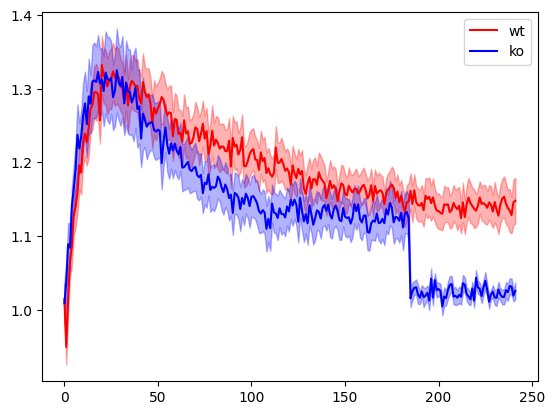

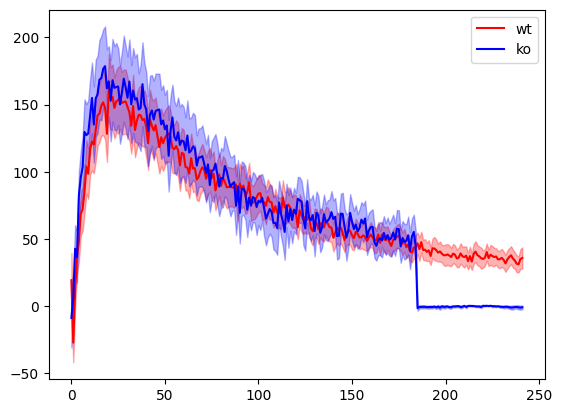

In [68]:
from experiment_loader import ExperimentType
from experiment_evaluator import ScoreType, plot_brightness_score_double, plot_brightness_score_wt_ko, calculate_brightness_score_for_videos, plot_brightness_score

ids, scores = calculate_brightness_score_for_videos(vids, score_type=ScoreType.Diff, range_modifier=range_modifier, cell_filter=cell_filter)

#plot_brightness_score_double(batch.experiments()[0], batch.experiments()[1], score_type=ScoreType.Diff, range_modifier=range_modifier, cell_filter=cell_filter)
plot_brightness_score_wt_ko(batch, score_type=ScoreType.Ratio, range_modifier=range_modifier, cell_filter=cell_filter)
plot_brightness_score_wt_ko(batch, score_type=ScoreType.Diff, range_modifier=range_modifier, cell_filter=cell_filter)

/home/sznistvan/projects/Cell_matyas/cell-segmentation-master/src/experiment_evaluator.py:464: RuntimeWarning: invalid value encountered in divide
  lasered = np.sum(frame[start:end,:]) / np.sum(mask[start:end,:])


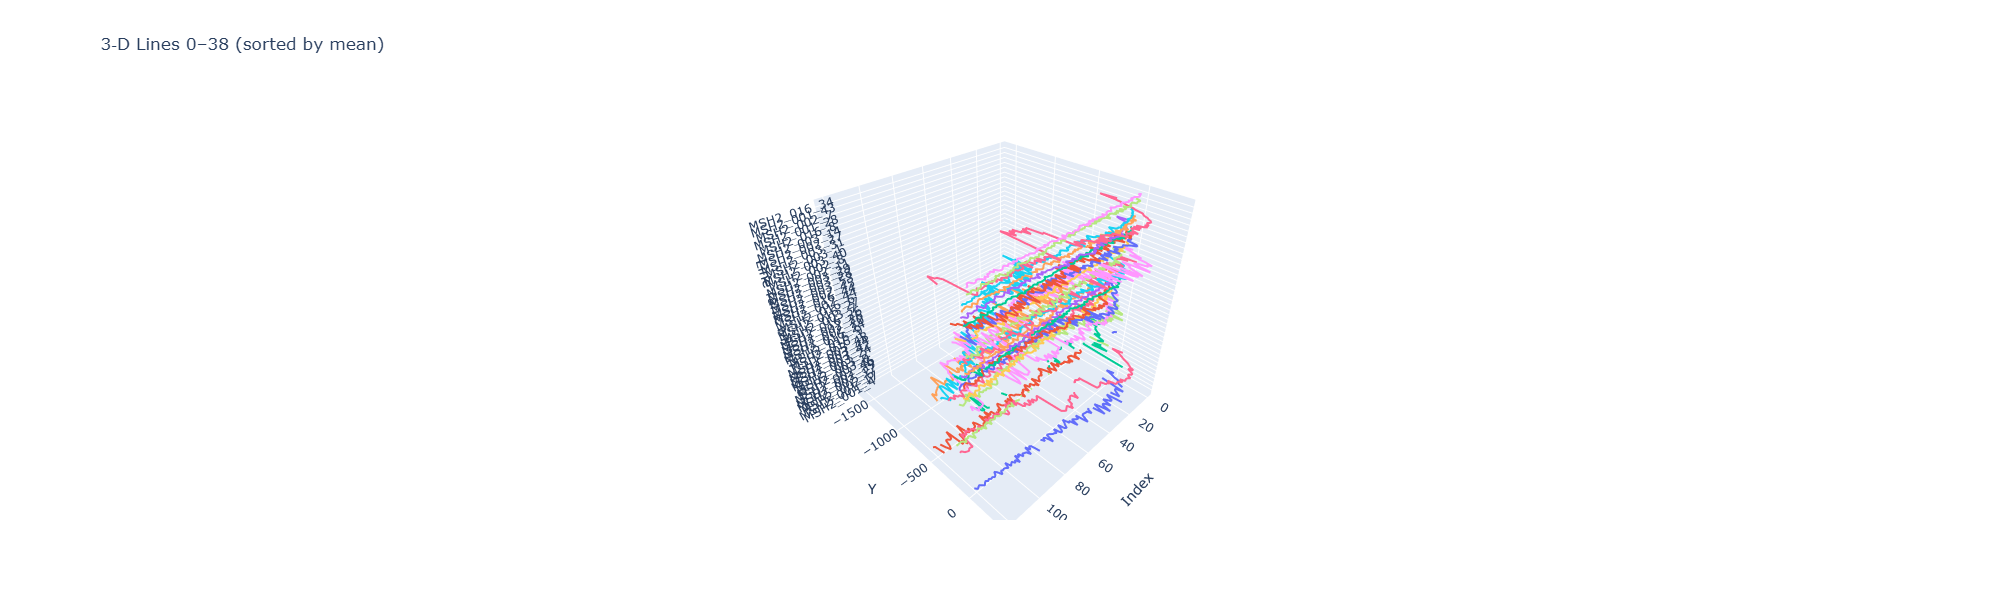

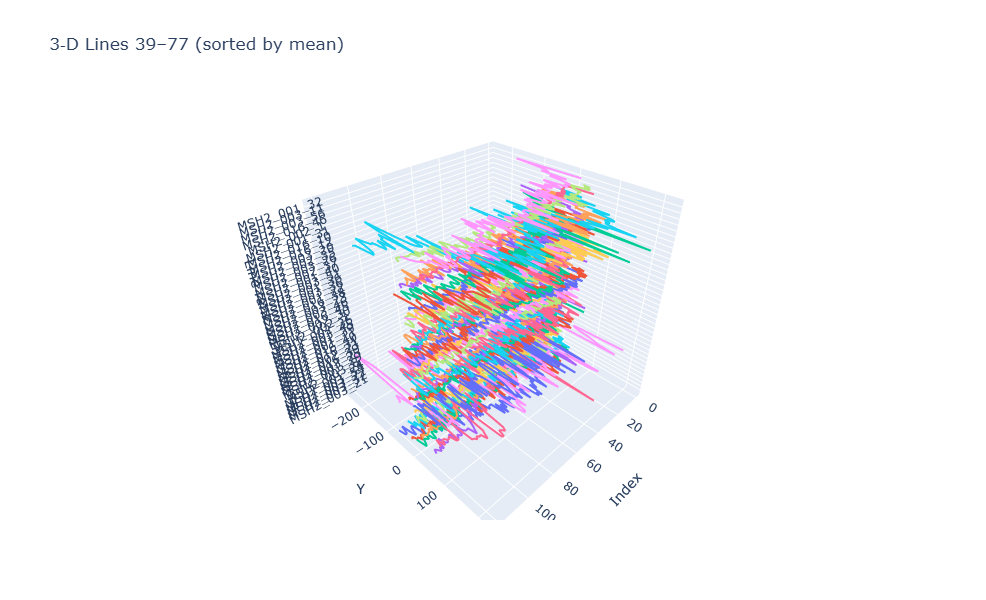

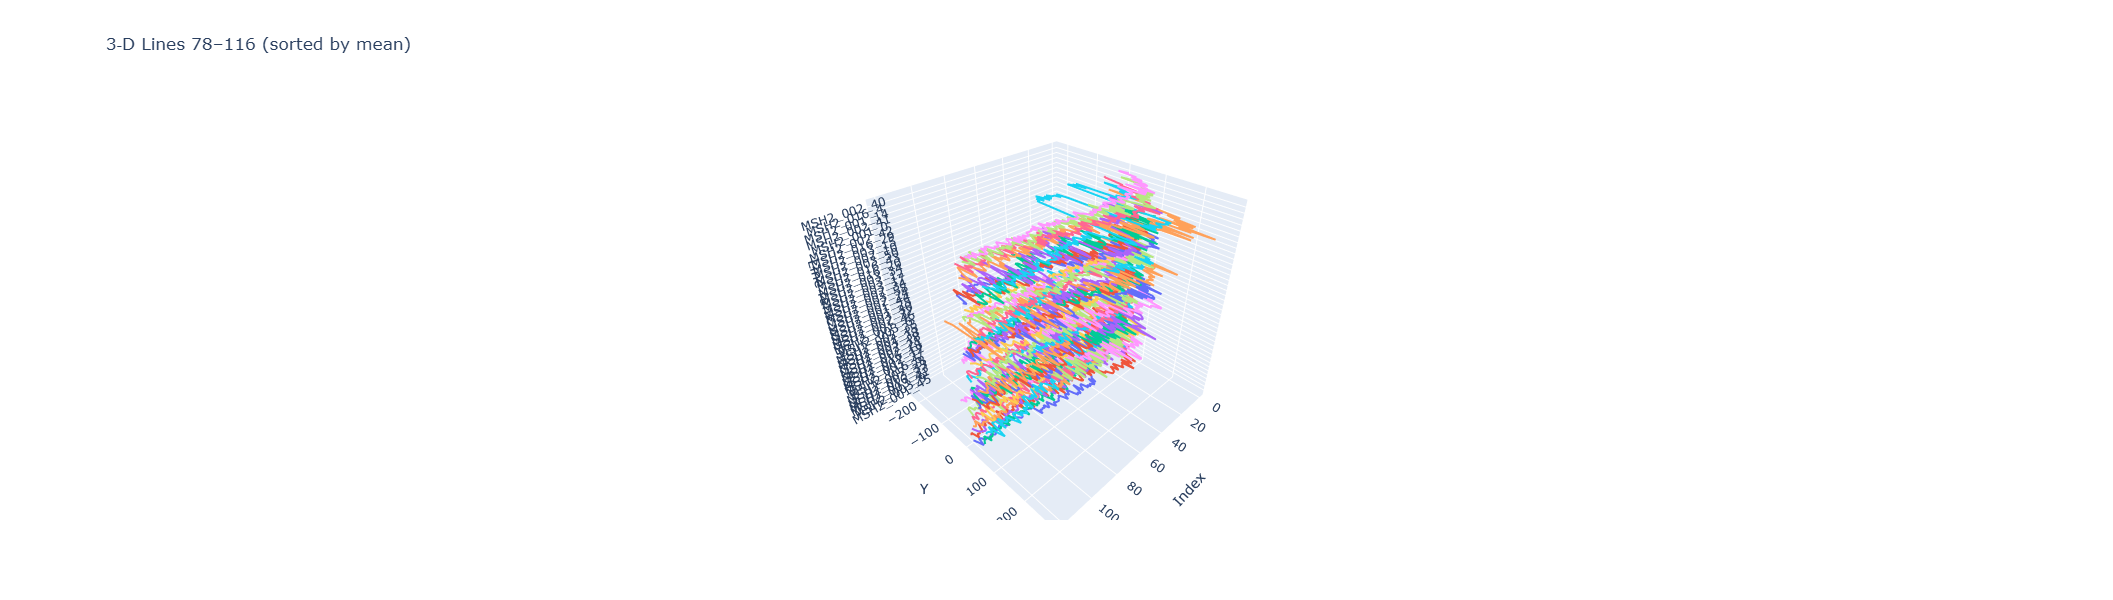

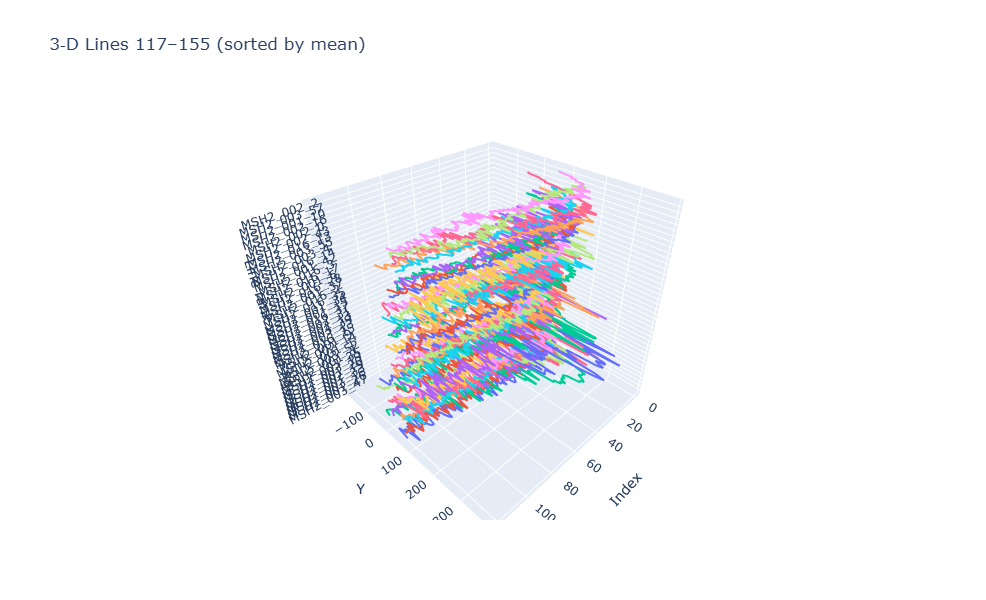

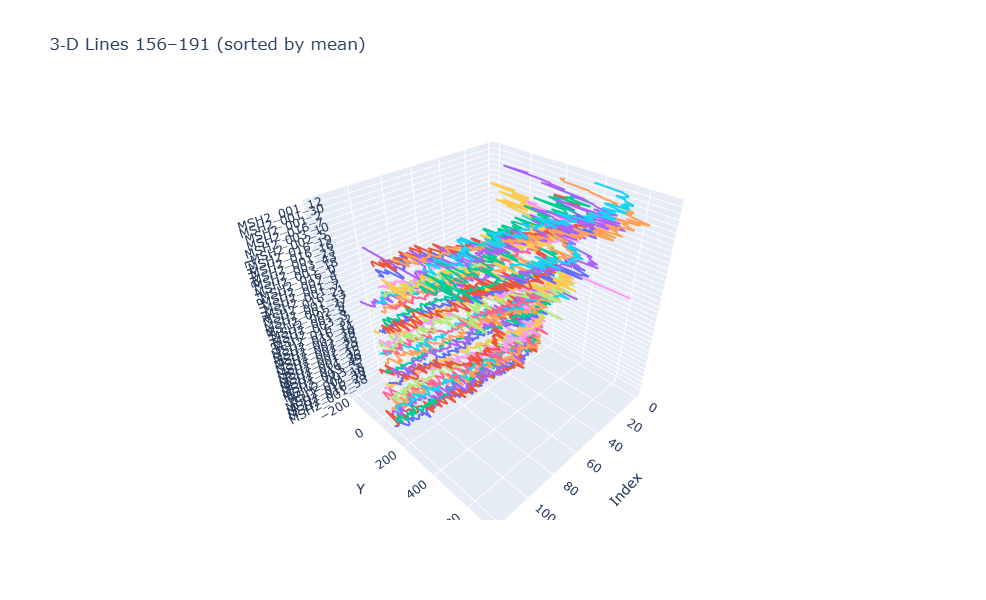

In [27]:
from experiment_evaluator import plot_all_vid_scores
from experiment_evaluator import calculate_brightness_score_for_videos, ExperimentType, ScoreType
ids, scores = calculate_brightness_score_for_videos(vids, score_type=ScoreType.Diff, range_modifier=range_modifier, cell_filter=cell_filter)
plot_all_vid_scores(scores, ids)